# 03 · Model comparison and probability diagnostics

A nested chronological model experiment on the exact 3,106-candidate feature store from notebook 02. Training-only screening is repeated inside every candidate fit and persisted with each estimator. Saved outputs below are validated against their recorded feature fingerprint.

In [1]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from march_mania.modeling import candidates, columns_for
from march_mania.notebook_support import table, style
from march_mania.publication.workflow import evidence, execution_mode, lineage, model_stage
from march_mania.runtime import EventLog

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
STARTED = time.monotonic()
LOG = EventLog(ROOT / "outputs/validation/model_notebook.jsonl")
LOG.emit("notebook_started", notebook="03_model_comparison_and_diagnostics")
style()
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "figure.facecolor": "white"})
MODE = execution_mode()  # Set to "train" to fit/resume on notebook 02's current matrix.
if MODE == "train":
    MODEL_RUN = model_stage(ROOT)
RESULTS, RECORD = evidence(ROOT, "model_comparison")
SUMMARY = RECORD["summary"]
SOURCE = f"verified persisted model experiment; notebook mode={MODE}"
lineage(ROOT)  # A mismatched feature-to-model dependency stops the notebook.
assert RESULTS is not None, "No completed model comparison evidence is available"
CONFIG = json.loads((ROOT / "configs/model_comparison.json").read_text())
display(Markdown(f"**Evidence source:** {SOURCE}. **Run:** `{SUMMARY['fingerprint']}`."))

{"elapsed_seconds": 0.0, "event": "notebook_started", "memory_status": "available", "notebook": "03_model_comparison_and_diagnostics", "rss_mb": 257.9, "timestamp": "2026-09-09T21:31:35.575611+00:00"}


**Evidence source:** verified persisted model experiment; notebook mode=review. **Run:** `20e69d30dc746f39f9395f96d1ff13d7a24cb0a7998fd096a0409c31fa7d7193`.

## 1. Where this fits

Read **00 → 01 → 02 → 03** to follow the analysis. Each notebook loads persisted evidence, so opening 03 does not depend on having executed earlier notebook cells.

- **00:** official download, checksums, raw-data inventory and basketball exploration.
- **01:** pre-tournament cutoff and chronological splits.
- **02:** 3,106 candidate features, measured family ablations and explicit feature-building control.
- **03:** model selection, probability calibration and ensembles using that feature store.
- **04:** the current retrospective benchmark plus user-controlled local CSV generation. No Kaggle upload is automatic.

The canonical Python engine is `src/march_mania/modeling.py`. The executed notebook is the analytical narrative; functions and tests provide reusable, independently checkable implementation.

In [2]:
table(pd.DataFrame([
    {"measure": "Candidate model fits", "value": SUMMARY["fit_tasks"]},
    {"measure": "Outer selection contexts", "value": SUMMARY["selection_tasks"]},
    {"measure": "Unique outer tournament games", "value": SUMMARY["physical_validation_games"]},
    {"measure": "Saved prediction rows", "value": SUMMARY["prediction_rows"]},
    {"measure": "Measured candidate fit seconds", "value": SUMMARY["training_seconds"]},
    {"measure": "Run elapsed seconds", "value": SUMMARY["elapsed_seconds"]},
]))
assert SUMMARY["feature_fingerprint"] == json.loads(
    (ROOT / "reports/feature_store/run.json").read_text())["summary"]["fingerprint"]
LOG.emit("feature_lineage_verified", feature_fingerprint=SUMMARY["feature_fingerprint"])

measure,value
Candidate model fits,861.000000
Outer selection contexts,20.000000
Unique outer tournament games,649.000000
Saved prediction rows,16282.000000
Measured candidate fit seconds,271.392000
Run elapsed seconds,291.121000


{"elapsed_seconds": 0.166, "event": "feature_lineage_verified", "feature_fingerprint": "199b4c00a8b59393a1290727ca6e0e5b9f9bbc5a17db18e1b02354229e5eed89", "memory_status": "available", "rss_mb": 260.3, "timestamp": "2026-09-09T21:31:35.741198+00:00"}


## 2. Bounded models on a broad candidate space

Candidate generation is broad; fitting is not a blind 3,106-variable model. Each candidate performs training-only missingness, near-constant, redundancy and association screening, retaining at most 128 inputs. Logistic regression, histogram boosting, XGBoost and LightGBM are compared using explicit feature blocks and compact penalty/tree-size choices. The logistic search includes all seven new domain groups individually, alongside the existing compact blocks and full screened bank. This is retrospective research on the same development seasons as notebook 02, not independent confirmation of its best feature score. Men-only ranking families are kept separate from pooled/common no-Massey models. No validation observations fit the screen or the imputer.

In [3]:
search_rows = []
for route in ["M", "W", "pooled_common"]:
    for candidate in candidates(route):
        search_rows.append({"route": route, "family": candidate.family,
                            "candidate": candidate.name, "block": candidate.block,
                            "features": len(columns_for(candidate))})
search = pd.DataFrame(search_rows)
table(search.groupby(["route", "family"]).agg(
    candidate_settings=("candidate", "nunique"), feature_groups=("block", "nunique"),
    smallest_matrix=("features", "min"), largest_matrix=("features", "max")
).reset_index())

route,family,candidate_settings,feature_groups,smallest_matrix,largest_matrix
M,hist,4,2,6,3083
M,lightgbm,4,2,6,3083
M,logistic,24,12,6,3083
M,rank_lightgbm,4,2,19,3106
M,rank_logistic,4,2,19,3106
M,rank_xgboost,4,2,19,3106
M,seed,1,1,1,1
M,xgboost,4,2,6,3083
W,hist,4,2,6,3083
W,lightgbm,4,2,6,3083


## 3. Temporal selection, calibration and blending

For an outer season, every candidate is evaluated on earlier expanding-window folds. Mean season Brier selects one candidate per family. Calibration compares identity with temperature scaling using **forward-only inner calibration folds**, then fits the selected method on earlier OOF probabilities. Temperature scaling preserves team-swap symmetry.

The ensemble fits nonnegative weights summing to one, with regularization toward equal weights, on selected **raw** inner OOF streams. Calibration-adjusted training predictions are not substituted for honest base-model OOF predictions.

For the earliest outer season (2016), only 2014 and 2015 are available as inner validation years; calibration selection therefore has only one forward validation year. That is a real limitation, not extra evidence. All reported outer forecasts are scored only after these decisions.

In [4]:
selection = pd.read_csv(RESULTS / "selection.csv")
assert (selection.history_last_season < selection.Season).all()
assert (selection.history_seasons >= 2).all()
assert set(selection.Season) == set(CONFIG["validation_seasons"])
assert selection.temperature.between(0.5, 2.0).all()
table(selection.query("Season == 2021")[["Gender", "route", "family", "candidate",
                                        "calibration", "temperature", "history_last_season"]])
LOG.emit("temporal_decisions_verified", selected_family_folds=len(selection))

Gender,route,family,candidate,calibration,temperature,history_last_season
M,M,hist,hist_strength_2,identity,1.000000,2019
M,M,lightgbm,lightgbm_strength_3,identity,1.000000,2019
M,M,logistic,logistic_strength_1,identity,1.000000,2019
M,M,rank_lightgbm,rank_lightgbm_rankings_3,identity,1.000000,2019
M,M,rank_logistic,rank_logistic_0,identity,1.000000,2019
M,M,rank_xgboost,rank_xgboost_rankings_2,identity,1.000000,2019
M,M,seed,seed,temperature,0.772708,2019
M,M,xgboost,xgboost_strength_3,identity,1.000000,2019
W,W,hist,hist_strength_2,identity,1.000000,2019
W,W,lightgbm,lightgbm_strength_2,identity,1.000000,2019


{"elapsed_seconds": 8.158, "event": "temporal_decisions_verified", "memory_status": "available", "rss_mb": 261.9, "selected_family_folds": 115, "timestamp": "2026-09-09T21:31:43.733186+00:00"}


## 4. Recompute the metric from saved predictions

[Kaggle's official competition metric](https://www.kaggle.com/competitions/march-machine-learning-mania-2026) is **Brier score**, the mean squared error of the predicted win probability. Lower is better. We also report log loss, ROC AUC, average precision, precision/recall/F1 at 0.5, and calibration error.

The leaderboard contains both **game-weighted Brier** and **mean season Brier**. Model selection weights seasons equally so a season with extra play-in games does not receive more influence. The positive class is the lower TeamID winning; no tournament game is counted twice within a prediction stream.

In [5]:
prediction_file = RESULTS / "predictions.parquet"
predictions = (pd.read_parquet(prediction_file) if prediction_file.exists()
               else pd.read_csv(RESULTS / "predictions.csv"))
leaderboard = pd.read_csv(RESULTS / "leaderboard.csv")
metrics = pd.read_csv(RESULTS / "metrics_by_season.csv")
KEYS = ["Gender", "Season", "block", "model", "ID"]
assert not predictions.duplicated(KEYS).any()
assert predictions.p.between(0, 1).all() and np.isfinite(predictions.p).all()
assert set(predictions.Season) == set(CONFIG["validation_seasons"])
scored = predictions.assign(loss=(predictions.y - predictions.p) ** 2)
computed = scored.groupby(["Gender", "block", "model"]).loss.mean().rename("computed_brier")
check = leaderboard.merge(computed, on=["Gender", "block", "model"], validate="one_to_one")
assert np.allclose(check.brier, check.computed_brier, atol=1e-12, rtol=0)
season_check = scored.groupby(["Gender", "Season", "block", "model"]).loss.mean()
macro = season_check.groupby(["Gender", "block", "model"]).mean().rename("computed_macro")
check = check.merge(macro, on=["Gender", "block", "model"], validate="one_to_one")
assert np.allclose(check.macro_season_brier, check.computed_macro, atol=1e-12, rtol=0)
LOG.emit("metrics_recomputed", prediction_rows=len(predictions), streams=len(leaderboard))
table(leaderboard.sort_values(["Gender", "macro_season_brier"]).groupby("Gender").head(6)
      [["Gender", "block", "model", "macro_season_brier", "brier", "log_loss",
        "roc_auc", "average_precision", "games"]])

{"elapsed_seconds": 8.2, "event": "metrics_recomputed", "memory_status": "available", "prediction_rows": 16282, "rss_mb": 265.7, "streams": 50, "timestamp": "2026-09-09T21:31:43.775373+00:00"}


Gender,block,model,macro_season_brier,brier,log_loss,roc_auc,average_precision,games
M,pooled_common,blend,0.188396,0.188324,0.551972,0.790007,0.770448,334
M,pooled_common,xgboost_calibrated,0.188398,0.188343,0.551889,0.788222,0.763167,334
M,pooled_common,xgboost_raw,0.188398,0.188343,0.551889,0.788222,0.763167,334
M,M,rank_logistic_calibrated,0.188468,0.188403,0.554309,0.791703,0.769936,334
M,M,rank_logistic_raw,0.188468,0.188403,0.554309,0.791703,0.769936,334
M,pooled_common,lightgbm_calibrated,0.188611,0.188552,0.553580,0.788348,0.756947,334
W,W,logistic_calibrated,0.144823,0.144823,0.433497,0.876723,0.878005,315
W,W,logistic_raw,0.144823,0.144823,0.433497,0.876723,0.878005,315
W,pooled_common,logistic_raw,0.145906,0.145906,0.436233,0.874466,0.876034,315
W,pooled_common,blend,0.146494,0.146494,0.443318,0.873095,0.872331,315


## 5. Which models performed best?

The plots compare identical outer seasons. Both raw and calibrated results remain in the tables so an unsuccessful calibration step is visible. The minimum on this development scoreboard is a candidate for further work, not an independently confirmed final winner.

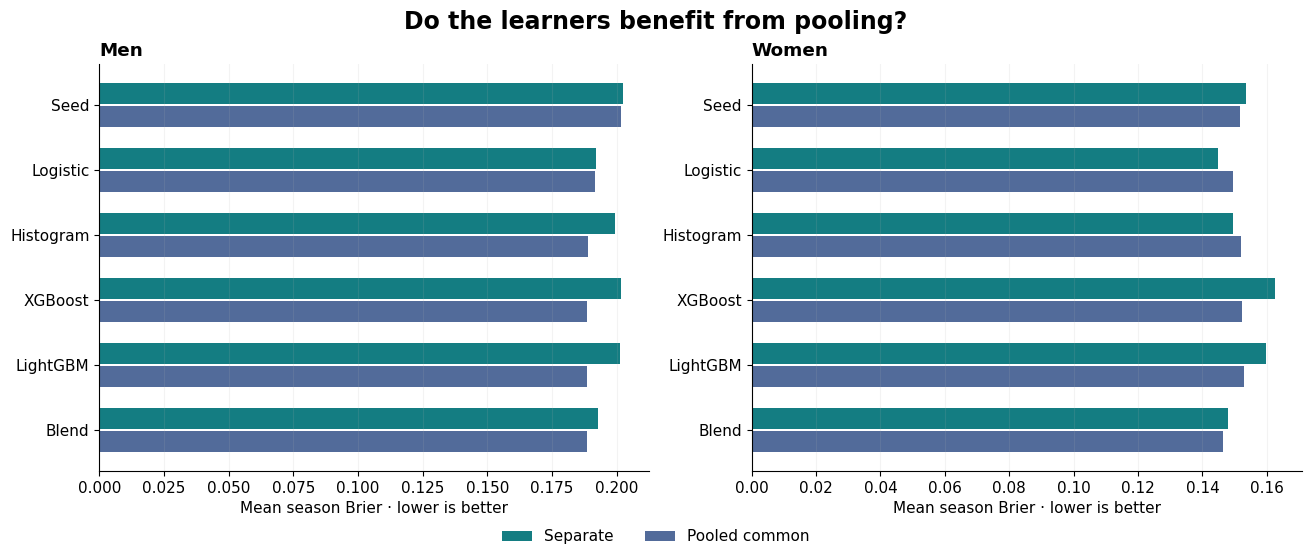

**Men:** lowest observed mean season Brier **0.188396**, `blend` / `pooled_common`.

**Women:** lowest observed mean season Brier **0.144823**, `logistic_calibrated` / `W`.

In [6]:
MODELS = ["seed_calibrated", "logistic_calibrated", "hist_calibrated",
          "xgboost_calibrated", "lightgbm_calibrated", "blend"]
LABELS = ["Seed", "Logistic", "Histogram", "XGBoost", "LightGBM", "Blend"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
for ax, gender, title in zip(axes, ["M", "W"], ["Men", "Women"]):
    for offset, route, color, label in [(-0.18, gender, "#147d82", "Separate"),
                                        (0.18, "pooled_common", "#526b9a", "Pooled common")]:
        panel = leaderboard.query("Gender == @gender and block == @route").set_index("model").loc[MODELS]
        ax.barh(np.arange(len(MODELS)) + offset, panel.macro_season_brier,
                height=0.32, color=color, label=label)
    ax.set_yticks(np.arange(len(MODELS)), LABELS)
    ax.invert_yaxis()
    ax.set_title(title, loc="left")
    ax.set_xlabel("Mean season Brier · lower is better")
    ax.grid(axis="x", alpha=0.15)
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="outside lower center", ncol=2, frameon=False)
fig.suptitle("Do the learners benefit from pooling?", fontsize=17, fontweight="bold")
plt.show()
winners = leaderboard.loc[leaderboard.groupby("Gender").macro_season_brier.idxmin()]
for row in winners.itertuples():
    display(Markdown(f"**{'Men' if row.Gender == 'M' else 'Women'}:** lowest observed mean season Brier "
                     f"**{row.macro_season_brier:.6f}**, `{row.model}` / `{row.block}`."))

## 6. Stability across seasons

A low average can hide a weak year. Tournament outcomes are dependent within seasons, and five seasons provide little information about long-term stability. The following chart keeps those variations visible.

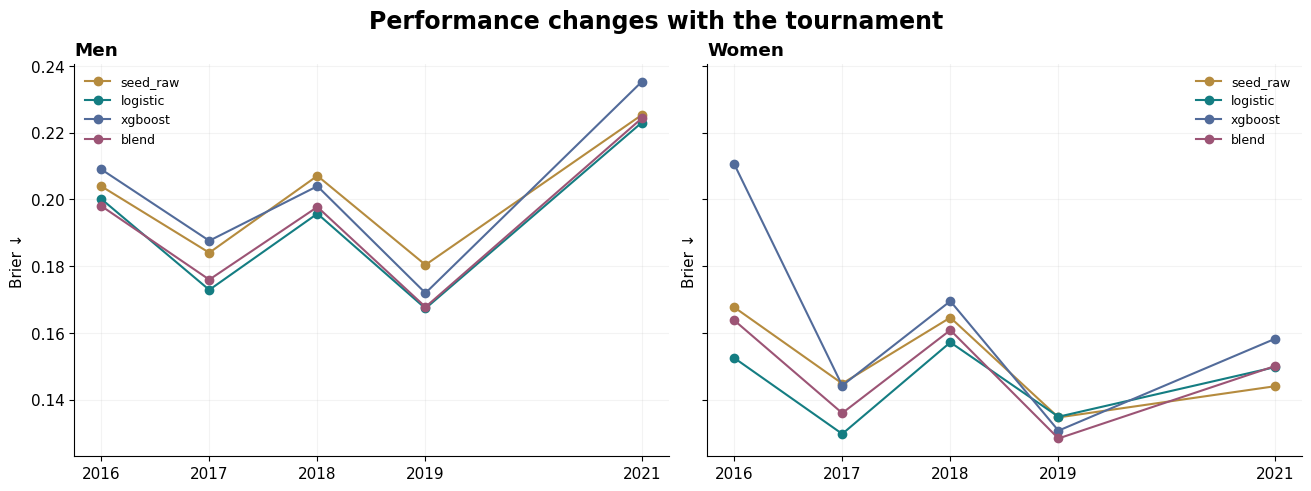

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, constrained_layout=True)
colors = {"seed_raw": "#b58b3e", "logistic_calibrated": "#147d82", "xgboost_calibrated": "#526b9a", "blend": "#9c5475"}
for ax, gender, title in zip(axes, ["M", "W"], ["Men", "Women"]):
    for model, color in colors.items():
        panel = metrics.query("Gender == @gender and block == @gender and model == @model")
        ax.plot(panel.Season, panel.brier, marker="o", label=model.replace("_calibrated", ""), color=color)
    ax.set_xticks(CONFIG["validation_seasons"])
    ax.set_title(title, loc="left")
    ax.set_ylabel("Brier ↓")
    ax.grid(alpha=0.15)
    ax.legend(frameon=False, fontsize=9)
fig.suptitle("Performance changes with the tournament", fontsize=17, fontweight="bold")
plt.show()

## 7. Calibration is measured, not assumed

A well-calibrated group of 70% predictions wins roughly 70% of the time. Bin counts matter: sparse bins can look extreme by chance. The diagonal is perfect calibration. Temperature scaling is retained only when it beats identity on earlier calibration validation years.

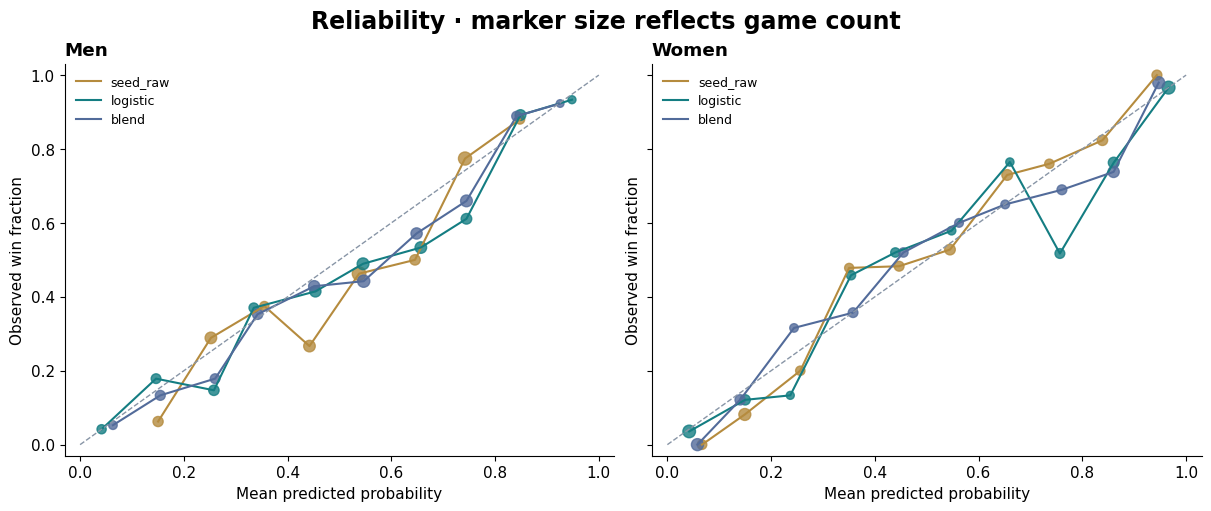

Gender,bin,predicted,observed,games
M,0,0.063328,0.052632,19
M,1,0.154579,0.133333,30
M,2,0.260272,0.178571,28
M,3,0.342210,0.352941,34
M,4,0.451355,0.428571,42
M,5,0.546707,0.442308,52
M,6,0.648690,0.571429,42
M,7,0.744830,0.659574,47
M,8,0.841346,0.888889,27
M,9,0.925408,0.923077,13


In [8]:
reliability = pd.read_csv(RESULTS / "reliability.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, gender, title in zip(axes, ["M", "W"], ["Men", "Women"]):
    for model, color in [("seed_raw", "#b58b3e"), ("logistic_calibrated", "#147d82"), ("blend", "#526b9a")]:
        panel = reliability.query("Gender == @gender and block == @gender and model == @model")
        ax.plot(panel.predicted, panel.observed, color=color, linewidth=1.5,
                label=model.replace("_calibrated", ""))
        ax.scatter(panel.predicted, panel.observed, s=15 + panel.games * 1.2, color=color, alpha=0.8)
    ax.plot([0, 1], [0, 1], linestyle="--", color="#8895a6", linewidth=1)
    ax.set(xlim=(-0.03, 1.03), ylim=(-0.03, 1.03), xlabel="Mean predicted probability", ylabel="Observed win fraction")
    ax.set_title(title, loc="left")
    ax.legend(frameon=False, fontsize=9)
fig.suptitle("Reliability · marker size reflects game count", fontsize=17, fontweight="bold")
plt.show()
table(reliability.query("model == 'blend' and block != 'pooled_common'")
      [["Gender", "bin", "predicted", "observed", "games"]])

## 8. Paired uncertainty against a seed-only baseline

Each interval resamples whole seasons, pairing the same games for the candidate and baseline. Negative Brier differences favor the candidate. These exploratory intervals do not adjust for the many comparisons made, and should not be read as proof that a selected winner will generalize.

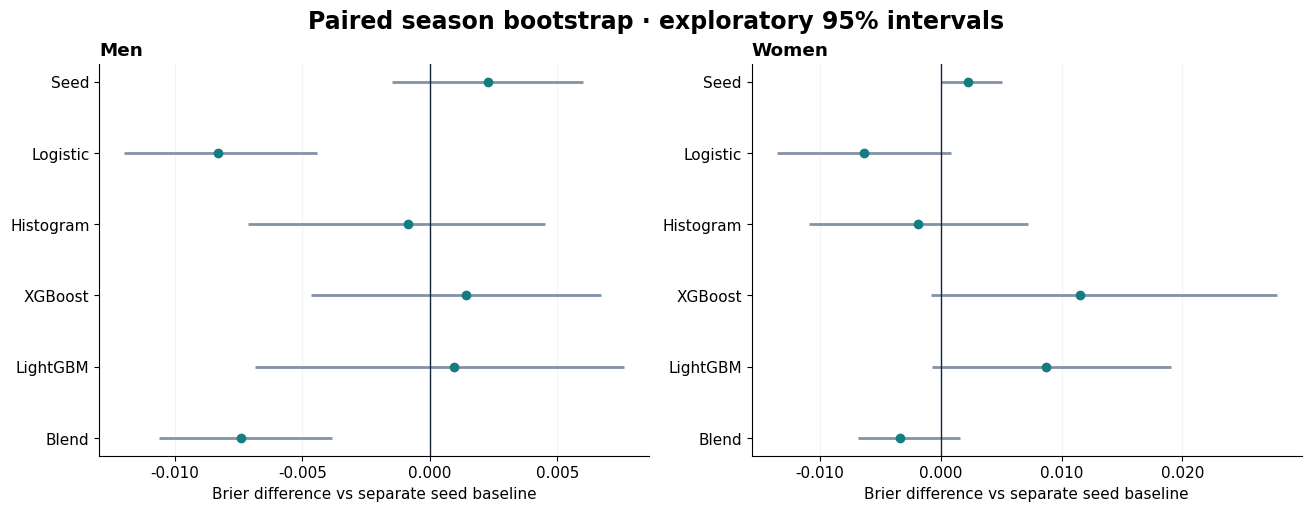

In [9]:
intervals = pd.read_csv(RESULTS / "paired_intervals.csv")
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, gender, title in zip(axes, ["M", "W"], ["Men", "Women"]):
    panel = intervals.query("Gender == @gender and block == @gender and model in @MODELS").set_index("model").loc[MODELS]
    y = np.arange(len(panel))
    ax.hlines(y, panel.ci_low, panel.ci_high, color="#8492a6", linewidth=2)
    ax.scatter(panel.brier_delta, y, color="#147d82", zorder=3)
    ax.axvline(0, color="#14243b", linewidth=1)
    ax.set_yticks(y, LABELS)
    ax.invert_yaxis()
    ax.set_title(title, loc="left")
    ax.set_xlabel("Brier difference vs separate seed baseline")
    ax.grid(axis="x", alpha=0.15)
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.3f"))
fig.suptitle("Paired season bootstrap · exploratory 95% intervals", fontsize=17, fontweight="bold")
plt.show()

## 9. What did the ensemble learn?

The weights below come only from earlier OOF games. They are constrained to sum to one and regularized toward equal weighting. The pooled models are trained jointly, but their settings and blend weights are selected separately for the men's and women's targets.

In [10]:
weights = pd.read_csv(RESULTS / "ensemble_weights.csv")
assert weights.weight.between(0, 1).all()
assert np.allclose(weights.groupby(["Gender", "route", "Season"]).weight.sum(), 1)
table(weights.query("Season == 2021").pivot(index=["Gender", "route"], columns="family", values="weight").reset_index())
LOG.emit("ensemble_contract_verified", contexts=len(weights.groupby(["Gender", "route", "Season"])))

family,Gender,route,hist,lightgbm,logistic,seed,xgboost
,M,M,0.044964,0.134411,0.545454,0.141686,0.133485
,M,pooled_common,0.157923,0.214643,0.367268,0.097609,0.162557
,W,W,0.193594,0.116557,0.445960,0.148737,0.095152
,W,pooled_common,0.157498,0.153242,0.480299,0.118717,0.090244


{"contexts": 20, "elapsed_seconds": 9.172, "event": "ensemble_contract_verified", "memory_status": "available", "rss_mb": 286.3, "timestamp": "2026-09-09T21:31:44.747706+00:00"}


## 10. Feature interpretation on held-out 2021 games

Permutation importance shuffles one feature and measures the increase in Brier while keeping the selected model fixed. Larger positive values indicate greater reliance on that feature in this fold. Correlated features can substitute for one another; shuffling can create unrealistic combinations. This is a diagnostic, not causal attribution or a rule for reselecting features on the same fold.

Five shuffles estimate permutation variability; they do not provide a statistical confidence interval across future tournaments.

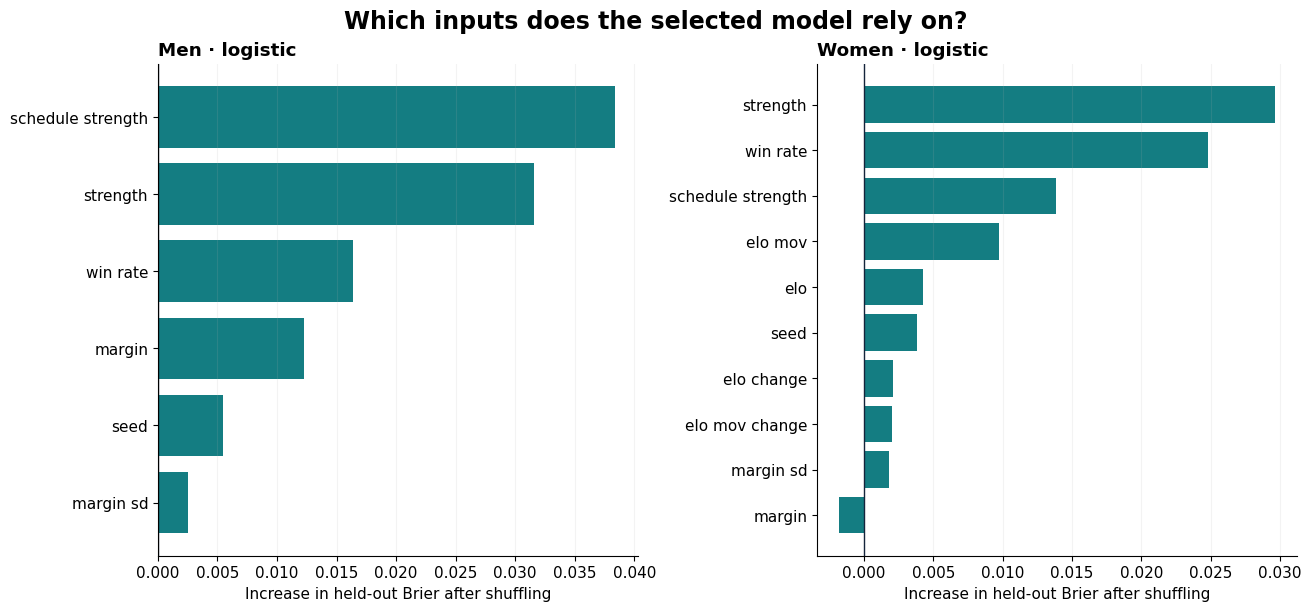

Gender,route,family,features_tested,repeats
M,M,hist,6,5
M,M,lightgbm,6,5
M,M,logistic,6,5
M,M,rank_lightgbm,15,5
M,M,rank_logistic,15,5
M,M,rank_xgboost,15,5
M,M,xgboost,6,5
M,pooled_common,hist,128,5
M,pooled_common,lightgbm,128,5
M,pooled_common,logistic,6,5


In [11]:
importance = pd.read_csv(RESULTS / "permutation.csv")
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
for ax, gender, title in zip(axes, ["M", "W"], ["Men · logistic", "Women · logistic"]):
    panel = importance.query("Gender == @gender and route == @gender and family == 'logistic'").nlargest(10, "brier_increase")
    labels = panel.feature.str.removeprefix("diff_").str.replace("_", " ")
    ax.barh(labels, panel.brier_increase, color="#147d82")
    ax.axvline(0, color="#14243b", linewidth=1)
    ax.invert_yaxis()
    ax.set_title(title, loc="left")
    ax.set_xlabel("Increase in held-out Brier after shuffling")
    ax.grid(axis="x", alpha=0.15)
fig.suptitle("Which inputs does the selected model rely on?", fontsize=17, fontweight="bold")
plt.show()
table(importance.groupby(["Gender", "route", "family"]).agg(features_tested=("feature", "nunique"), repeats=("repeats", "first")).reset_index())

## 11. Inspect the largest errors

Confident misses are useful basketball case studies. They do not by themselves justify changing a model: the evaluation set must not become an unacknowledged tuning target.

In [12]:
table(pd.read_csv(RESULTS / "largest_errors.csv").head(12)
      [["Gender", "Season", "ID", "block", "y", "p", "squared_error"]])
threshold_view = leaderboard.query("model == 'blend'")
table(threshold_view[["Gender", "block", "brier", "log_loss", "roc_auc", "average_precision",
                      "precision_at_05", "recall_at_05", "f1_at_05", "ece_10_bins"]])

Gender,Season,ID,block,y,p,squared_error
M,2018,2018_1420_1438,pooled_common,1,0.046344,0.909459
M,2018,2018_1420_1438,M,1,0.058137,0.887107
M,2016,2016_1277_1292,pooled_common,0,0.928902,0.862860
W,2016,2016_3268_3449,W,0,0.922808,0.851574
W,2016,2016_3268_3449,pooled_common,0,0.916282,0.839573
M,2016,2016_1277_1292,M,0,0.915737,0.838575
M,2021,2021_1326_1331,pooled_common,0,0.904143,0.817475
W,2018,2018_3124_3333,pooled_common,0,0.903406,0.816142
W,2019,2019_3235_3283,pooled_common,0,0.901697,0.813058
W,2018,2018_3138_3199,W,1,0.106809,0.797789


Gender,block,brier,log_loss,roc_auc,average_precision,precision_at_05,recall_at_05,f1_at_05,ece_10_bins
M,M,0.192674,0.562494,0.778716,0.759608,0.629834,0.740260,0.680597,0.055224
M,pooled_common,0.188324,0.551972,0.790007,0.770448,0.638889,0.746753,0.688623,0.078957
W,W,0.147820,0.446437,0.871120,0.868295,0.775000,0.789809,0.782334,0.051087
W,pooled_common,0.146494,0.443318,0.873095,0.872331,0.773006,0.802548,0.787500,0.056151


## 12. Bounded retraining after the observed submissions

The observed 2026 results motivated this retrospective follow-up. Repeating the same deterministic fit on unchanged data would reproduce the same model. Instead, seven declared recipes compare **120 versus 240 trees**, **strong versus lighter regularization**, **128 versus 64 retained features**, and **matched men's Massey/coach controls**. Four new recipes require 28 earlier-season fits; 21 existing control fits are reused from their verified prediction artifact.

All recipes use depth 2 and learning rate 0.04. Screening, imputation and fitting use strictly earlier seasons, with the first training season fixed at 2013. Each candidate is evaluated on the same 334 men's games in 2016–2019 and 2021. This fixed-recipe comparison differs from the broader nested model-family selection above. Neither these explored seasons nor the observed 2026 leaderboard is an untouched holdout. The frozen production recipe is preserved.


In [13]:
from march_mania.publication import retraining
RETRAIN_XGBOOST = False  # Explicit opt-in after restoring the verified inputs.
if RETRAIN_XGBOOST:
    retraining.run(ROOT, ROOT / "outputs/retraining_inputs")
retraining_summary = retraining.review(ROOT)
RETRAINING = ROOT / "reports/xgboost_retraining"
retraining_scores = pd.read_csv(RETRAINING / "leaderboard.csv")
retraining_choices = pd.read_csv(RETRAINING / "selection.csv")
assert retraining_choices.history_last_season.lt(retraining_choices.Season).all()
assert retraining_summary["new_fit_tasks"] == 28
assert retraining_summary["reused_control_fits"] == 21
table(retraining_scores[["variant", "games", "brier", "mean_season_brier", "log_loss", "roc_auc", "ece_10_bins", "improved_seasons"]])
table(retraining_choices)
table(pd.DataFrame([retraining_summary["forward_selection_metrics"]]))


variant,games,brier,mean_season_brier,log_loss,roc_auc,ece_10_bins,improved_seasons
pooled_64_features,334,0.184333,0.184403,0.543290,0.801190,0.071379,3
pooled_less_regularized,334,0.185088,0.185155,0.546608,0.797799,0.070183,2
pooled_240_trees,334,0.185116,0.185166,0.547760,0.799603,0.073188,3
pooled_reference,334,0.185134,0.185199,0.546071,0.797944,0.058835,0
men_massey_no_coach,334,0.191808,0.191867,0.564674,0.780988,0.066633,1
men_massey,334,0.192201,0.192258,0.565226,0.783478,0.062549,1
men_reference,334,0.193306,0.193366,0.567554,0.779654,0.075701,1


Season,variant,history_last_season,history_seasons
2016,pooled_less_regularized,2015,2
2017,pooled_64_features,2016,3
2018,pooled_64_features,2017,4
2019,pooled_64_features,2018,5
2021,pooled_64_features,2019,6


average_precision,brier,ece_10_bins,f1_at_05,games,log_loss,mean_season_brier,precision_at_05,recall_at_05,roc_auc
0.765667,0.185070,0.073055,0.722388,334,0.545950,0.185138,0.668508,0.785714,0.798954


candidate,baseline,brier_delta,ci_low,ci_high,season_count
pooled_64_features,pooled_reference,-0.000796,-0.004364,0.003439,5
pooled_less_regularized,pooled_reference,-0.000044,-0.001136,0.001000,5
pooled_240_trees,pooled_reference,-0.000033,-0.004431,0.004623,5
men_massey,men_reference,-0.001107,-0.004742,0.002527,5
men_massey_no_coach,men_massey,-0.000391,-0.005510,0.004031,5


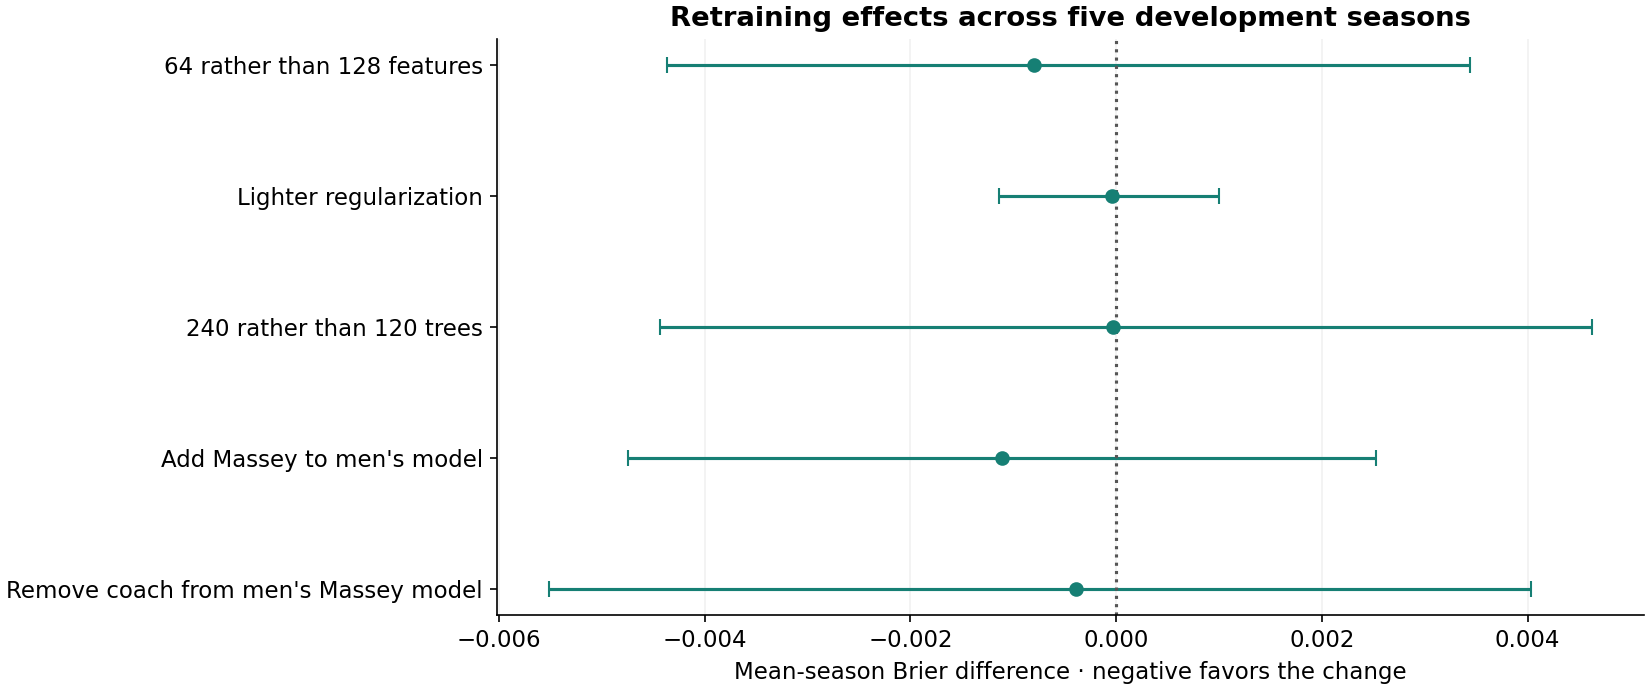

In [14]:
import base64
import io
import plotly.express as px
from march_mania.research_report import paired_season_intervals

retraining_predictions = pd.read_csv(RETRAINING / "predictions.csv")
paired = retraining_predictions.query("Season in [2016, 2017, 2018, 2019, 2021]").rename(columns={"variant": "block"}).assign(model="xgboost", Gender="M")
comparisons = [(name, "pooled_reference") for name in ["pooled_64_features", "pooled_less_regularized", "pooled_240_trees"]]
comparisons += [("men_massey", "men_reference"), ("men_massey_no_coach", "men_massey")]
retraining_intervals = paired_season_intervals(paired, 2026, comparisons)
table(retraining_intervals[["candidate", "baseline", "brier_delta", "ci_low", "ci_high", "season_count"]])
chart = retraining_intervals.copy()
chart["comparison"] = ["64 rather than 128 features", "Lighter regularization", "240 rather than 120 trees", "Add Massey to men's model", "Remove coach from men's Massey model"]
chart["upper"] = chart.ci_high - chart.brier_delta
chart["lower"] = chart.brier_delta - chart.ci_low
title = "Retraining effects across five development seasons"
interactive = px.scatter(chart, x="brier_delta", y="comparison", error_x="upper", error_x_minus="lower", hover_data=["candidate", "baseline", "ci_low", "ci_high"], title=title, height=430)
interactive.update_layout(template="plotly_white", margin=dict(l=280, r=35, t=65, b=65), xaxis_title="Mean-season Brier difference · negative favors the change", yaxis_title=None)
interactive.update_traces(marker=dict(size=10, color="#167f74"))
interactive.add_vline(x=0, line_color="#555555", line_dash="dot")
interactive.update_yaxes(autorange="reversed")
static, axis = plt.subplots(figsize=(11, 4.6), constrained_layout=True)
axis.errorbar(chart.brier_delta, chart.comparison, xerr=np.vstack([chart.lower, chart.upper]), fmt="o", color="#167f74", capsize=4)
axis.axvline(0, color="#555555", linestyle=":")
axis.invert_yaxis()
axis.set(title=title, xlabel="Mean-season Brier difference · negative favors the change")
axis.grid(axis="x", alpha=.18)
png = io.BytesIO()
static.savefig(png, format="png", dpi=150)
plt.close(static)
display({"application/vnd.plotly.v1+json": json.loads(interactive.to_json()), "image/png": base64.b64encode(png.getvalue()).decode()}, raw=True)


**What changed?** The fixed 64-feature pooled model improves men's game-weighted Brier from **0.185134 to 0.184333**, winning three of five seasons. Doubling the trees and reducing regularization are effectively tied with the reference. All five exploratory season-bootstrap intervals above include zero; they resample complete seasons and are not corrected for multiple comparisons.

Choosing the recipe using only earlier out-of-fold seasons produces **0.185070** game-weighted Brier, just **0.000064** below the pooled reference; calibration error is worse (**0.0731 versus 0.0588**). The best fixed recipe is promising, but these results do not establish a dependable retraining gain.

**Massey and coaches.** In the matched men's XGBoost controls, adding Massey improves Brier from **0.193306 to 0.192201**. Removing coach features from that Massey recipe further improves it to **0.191808**. Both still trail the pooled reference. These are conditional pipeline effects: changing the eligible bank can change the retained screen. Earlier compact histogram ablations showed a larger Massey benefit, while coach effects varied across models and seasons. The submitted pooled XGBoost winner excludes Massey and retained no coach inputs in either its seeded or seed-free final screen.

**Decision:** keep the original production reference and archive the complete retraining evidence. A 64-feature pooled challenger is the most defensible candidate to freeze for a genuinely future evaluation. Another leaderboard blend sweep would not resolve the weak temporal evidence. See the [retraining report](../reports/xgboost_retraining/README.md) for exact recipes, coverage and model checkpoints.


## Women’s logistic challengers

Women’s logistic regression won every combination in the observed 50-file Kaggle batch. That supports keeping it as the reference while checking nearby alternatives. This bounded comparison evaluates five raw recipes at temperatures 0.90, 1.00 and 1.10: conference logistic C=0.10, 0.30, 1.00 and 3.00, plus dynamic logistic C=0.30. C=0.30 conference and dynamic predictions reuse the saved candidate folds; the other three require 21 historical fits.

Each validation year uses only earlier women’s tournament seasons starting in 2013. The matched development population is 315 games in 2016–2019 and 2021, with 2014–2015 used as selection warmup. These years were already explored. Temperature 1.10 moves probabilities toward 0.5; it is a fixed sensitivity hypothesis, not a calibration model fitted on the evaluated outcomes. Five-season bootstrap intervals are exploratory and unadjusted for model selection.

**Result:** the reference conference model with temperature 1.10 leads at **0.142167** Brier versus **0.142891** for its original probabilities. Its log loss improves from the original as well. However, choosing among these hypotheses using only earlier folds produces **0.145277** Brier. That weaker forward-selection result limits the claim: this is a small submission experiment, not proof of reliable improvement. Only two alternatives have a lower fixed historical Brier than the unchanged reference, and the second is effectively tied. Women’s Massey and coach histories are unavailable in this snapshot, so those men’s inputs cannot be assumed available for women.


In [15]:
import runpy
women_api = runpy.run_path(str(ROOT / "scripts/women_challengers.py"))
RUN_WOMEN_STUDY = False
if RUN_WOMEN_STUDY:
    women_api["study"](ROOT, ROOT / "outputs/retraining_inputs")
women_study = women_api["review"](ROOT)
women_report = ROOT / women_api["REPORT"]
women_leaders = pd.read_csv(women_report / "leaderboard.csv")
women_finalists = pd.read_csv(women_report / "finalists.csv")
reference = women_leaders.loc[women_leaders.candidate_id.eq("conference_c030_t100")]
table(pd.concat([reference.assign(role="Reference"), women_finalists.assign(role="Challenger")])[
    ["role", "candidate_id", "brier", "mean_season_brier", "log_loss", "ece_10_bins", "brier_delta", "ci_low", "ci_high"]
], {key: "{:.6f}" for key in ["brier", "mean_season_brier", "log_loss", "ece_10_bins", "brier_delta", "ci_low", "ci_high"]})
table(pd.DataFrame([{"Protocol": "Choose using strictly earlier seasons", **women_study["forward_selection_metrics"]}]))
display(Markdown("The six alternatives exclude the unchanged reference and are ranked by historical mean-season Brier. Equal game counts per development year make the two Brier definitions equal here. No 2026 outcomes enter fitting or selection. [Full study and reproducibility](../reports/women_challengers/README.md)."))


role,candidate_id,brier,mean_season_brier,log_loss,ece_10_bins,brier_delta,ci_low,ci_high
Reference,conference_c030_t100,0.142891,0.142891,0.430224,0.076111,0.000000,0.000000,0.000000
Challenger,conference_c030_t110,0.142167,0.142167,0.428623,0.077605,-0.000724,-0.001501,-0.000044
Challenger,conference_c010_t110,0.142881,0.142881,0.431307,0.054794,-0.000010,-0.001293,0.001026
Challenger,conference_c100_t110,0.142958,0.142958,0.431042,0.071470,0.000067,-0.002574,0.002803
Challenger,dynamic_c030_t110,0.143116,0.143116,0.429099,0.062747,0.000226,-0.003957,0.004728
Challenger,conference_c010_t100,0.143331,0.143331,0.431200,0.064649,0.000441,-0.000352,0.001233
Challenger,dynamic_c030_t100,0.143867,0.143867,0.429935,0.062455,0.000976,-0.003792,0.005995


Protocol,average_precision,brier,ece_10_bins,f1_at_05,games,log_loss,mean_season_brier,precision_at_05,recall_at_05,roc_auc
Choose using strictly earlier seasons,0.876478,0.145277,0.058048,0.783699,315,0.435033,0.145277,0.771605,0.796178,0.875796


The six alternatives exclude the unchanged reference and are ranked by historical mean-season Brier. Equal game counts per development year make the two Brier definitions equal here. No 2026 outcomes enter fitting or selection. [Full study and reproducibility](../reports/women_challengers/README.md).

## 13. Interpretation and completed modeling scope

Notebook 05 now reads this exact model experiment and notebook 02's feature evidence. Its score changes refer to matched development games, not historical Kaggle submissions. The old 120-fold compact study and August 2026 score log remain historical references only.

The ranked-tree extension tests a specific missing comparison: whether ordinal ranking consensus helps nonlinear models after controlling the folds and scoring population. Feature block/depth selection and optional calibration remain inside earlier-season folds. Notebook 04 evaluates declared logistic anchors frozen from pre-2022 forecasts; it does not promote the observed development winner.

Historical neural and margin models were **not** retrained in this experiment. A current-schema neural or margin challenger requires its own earlier-season tuning, ablations and model-selection evidence; the old numbers cannot substitute for that work. The already-consumed 2022–2025 benchmark is not reused to choose new features. **No Kaggle submission is sent by this notebook.**

**Measured outcome:** the men’s lowest observed mean-season Brier is 0.188396 from the no-Massey pooled blend; ranking logistic scores 0.188468. Women’s separate logistic scores 0.144823. The earlier 124-feature minima were 0.188476 and 0.143867: effectively a tie for men and a regression for women. Four of five men’s pooled tree decisions use a screened full-bank candidate, but women’s expanded logistic choices do not improve the overall result. The family ablations do not establish reliable coach, target-encoding or Massey gains across future seasons.

In [16]:
recovery_path = RESULTS / "research_recovery.json"
if recovery_path.exists():
    recovery = json.loads(recovery_path.read_text())
    assert recovery["fingerprint"] == SUMMARY["fingerprint"]
    assert recovery["repeated_tasks"] == 0 and recovery["identical_predictions"]
    table(pd.DataFrame([recovery]))

historical = pd.read_csv(ROOT / "reports/modeling/03_model_comparison/matched_season_model_comparison.csv")
display(Markdown(f"Historical comparison retained: **{len(historical)} rows**. "
                 "Use its original reports for schema-specific details; no exact paired claim is made here."))
LOG.emit("notebook_completed", total_seconds=round(time.monotonic() - STARTED, 3),
         verified_streams=len(leaderboard), physical_games=SUMMARY["physical_validation_games"])
display(Markdown("**Notebook 03 complete.** Saved outputs include metric verification, "
                 "temporal audits, calibration, ensemble checks and held-out interpretation."))

archive_sha256,archive_version_id,fingerprint,identical_predictions,recovery_source,repeated_tasks,restored_tasks,reused_tasks,status
54031ef705ffa2b5433d8e016ab6fdc87441ceece41a6d90743b68c2f61f3f4b,c.pwIGt6AJc_xuvsaV_jHi4Jy4hIhmVB,20e69d30dc746f39f9395f96d1ff13d7a24cb0a7998fd096a0409c31fa7d7193,True,fresh SHA-256-verified S3 archive download,0,901,901,passed


Historical comparison retained: **54 rows**. Use its original reports for schema-specific details; no exact paired claim is made here.

{"elapsed_seconds": 10.809, "event": "notebook_completed", "memory_status": "available", "physical_games": 649, "rss_mb": 320.3, "timestamp": "2026-09-09T21:31:46.384368+00:00", "total_seconds": 10.809, "verified_streams": 50}


**Notebook 03 complete.** Saved outputs include metric verification, temporal audits, calibration, ensemble checks and held-out interpretation.

## Reproduction and durable artifacts

**Final release:** all 70 current submissions are scored. The observed best is **0.1222672**, using pooled men’s XGBoost T=0.90 and women’s conference logistic C=1.0/T=1.10. These leaderboard observations are distinct from the historical metrics above; notebook 04 presents the final result and complete score ledger.

The published notebook already contains its outputs. Reviewers can inspect it without running anything. Maintainers can reproduce the experiment with `march-models`, which verifies and reuses completed candidate fits. Supplying `--s3` replicates each completed task to private S3.

```bash
.venv/bin/march-models --s3 s3://sagemaker-march-mania-560403859723-us-west-2/model-comparison
.venv/bin/python scripts/notebook.py --execute --publish
```

UTC timestamped events include task start/completion, elapsed time, progress, and 15-second heartbeats during long tasks. Failed tasks do not receive a completion checkpoint. Checkpoints include output SHA-256 hashes, input/config/source fingerprints, and model artifacts. A matching successful fit is reused; a damaged fit is recomputed.

`reports/model_comparison/run.json` records exact source/input hashes, the private archive URI, and its checksum. The archive includes model artifacts, predictions, the feature matrix and exact Python sources. The standalone interactive report accompanies the archive and the compact CSV evidence is published with this notebook.

Technical references: [XGBoost parameters](https://xgboost.readthedocs.io/en/release_3.1.0/parameter.html), [LightGBM 4.6 parameters](https://lightgbm.readthedocs.io/en/v4.6.0/Parameters.html), [official competition](https://www.kaggle.com/competitions/march-machine-learning-mania-2026).